In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import threshold_niblack, threshold_sauvola
from sklearn.metrics import confusion_matrix



In [4]:


BASE_DIR = "/kaggle/input/drive-digital-retinal-images-for-vessel-extraction/DRIVE/training"

IMG_DIR = os.path.join(BASE_DIR, "images")
GT_DIR = os.path.join(BASE_DIR, "1st_manual")
MASK_DIR = os.path.join(BASE_DIR, "mask")

image_list = sorted(os.listdir(IMG_DIR))
gt_list = sorted(os.listdir(GT_DIR))
mask_list = sorted(os.listdir(MASK_DIR))

print("Number of training images:", len(image_list))



Number of training images: 20


In [5]:


def enhance_green_channel(img_path):
    img = cv2.imread(img_path)
    
    # Extract green channel (best for vessels)
    green_channel = img[:, :, 1]
    
    # Apply CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    enhanced_img = clahe.apply(green_channel)
    
    return enhanced_img

In [6]:


def get_thin_vessels(gt_mask):
    binary_mask = gt_mask // 255
    
    kernel = np.ones((3,3), np.uint8)
    eroded_mask = cv2.erode(binary_mask, kernel, iterations=1)
    
    thin_vessels = binary_mask - eroded_mask
    thin_vessels[thin_vessels < 0] = 0
    
    return thin_vessels

In [7]:


def apply_niblack(img):
    threshold = threshold_niblack(img, window_size=35, k=-0.9)
    segmented = (img < threshold).astype(np.uint8)
    
    segmented = cv2.morphologyEx(segmented, cv2.MORPH_OPEN, np.ones((2,2), np.uint8))
    return segmented


def apply_sauvola(img):
    threshold = threshold_sauvola(img, window_size=45, k=0.2)
    segmented = (img < threshold).astype(np.uint8)
    
    segmented = cv2.morphologyEx(segmented, cv2.MORPH_OPEN, np.ones((2,2), np.uint8))
    return segmented


In [8]:


def evaluate_performance(gt, pred, fov_mask):
    
    valid_pixels = (fov_mask // 255).flatten() == 1
    
    gt = gt.flatten()[valid_pixels]
    pred = pred.flatten()[valid_pixels]
    
    tn, fp, fn, tp = confusion_matrix(gt, pred, labels=[0,1]).ravel()
    
    sensitivity = tp / (tp + fn + 1e-8)
    specificity = tn / (tn + fp + 1e-8)
    accuracy = (tp + tn) / (tp + tn + fp + fn + 1e-8)
    
    return sensitivity, specificity, accuracy



In [9]:


niblack_scores = []
sauvola_scores = []

for i in range(len(image_list)):
    
    img = enhance_green_channel(os.path.join(IMG_DIR, image_list[i]))
    gt = cv2.imread(os.path.join(GT_DIR, gt_list[i]), 0)
    fov = cv2.imread(os.path.join(MASK_DIR, mask_list[i]), 0)
    
    thin_gt = get_thin_vessels(gt)
    
    niblack_pred = apply_niblack(img)
    sauvola_pred = apply_sauvola(img)
    
    n_metrics = evaluate_performance(thin_gt, niblack_pred, fov)
    s_metrics = evaluate_performance(thin_gt, sauvola_pred, fov)
    
    niblack_scores.append(n_metrics)
    sauvola_scores.append(s_metrics)


niblack_scores = np.array(niblack_scores)
sauvola_scores = np.array(sauvola_scores)

In [10]:


best_niblack_idx = np.argmax(niblack_scores[:, 0])
best_sauvola_idx = np.argmax(sauvola_scores[:, 0])

print("\nBest Sensitivity Results")
print("------------------------")
print("Niblack Best Sensitivity :", niblack_scores[best_niblack_idx, 0])
print("Image Index              :", best_niblack_idx)

print("\nSauvola Best Sensitivity :", sauvola_scores[best_sauvola_idx, 0])
print("Image Index              :", best_sauvola_idx)



Best Sensitivity Results
------------------------
Niblack Best Sensitivity : 0.9599782358980956
Image Index              : 11

Sauvola Best Sensitivity : 0.40294480771850427
Image Index              : 13


In [11]:


print("\nFinal Average Performance")
print("--------------------------")

print("\nNIBLACK")
print("Average Sensitivity :", np.mean(niblack_scores[:,0]))
print("Average Specificity :", np.mean(niblack_scores[:,1]))
print("Average Accuracy    :", np.mean(niblack_scores[:,2]))

print("\nSAUVOLA")
print("Average Sensitivity :", np.mean(sauvola_scores[:,0]))
print("Average Specificity :", np.mean(sauvola_scores[:,1]))
print("Average Accuracy    :", np.mean(sauvola_scores[:,2]))



Final Average Performance
--------------------------

NIBLACK
Average Sensitivity : 0.94303508253244
Average Specificity : 0.15955274768664343
Average Accuracy    : 0.22262613379209878

SAUVOLA
Average Sensitivity : 0.30432331886528075
Average Specificity : 0.9257397810720631
Average Accuracy    : 0.875593325213521


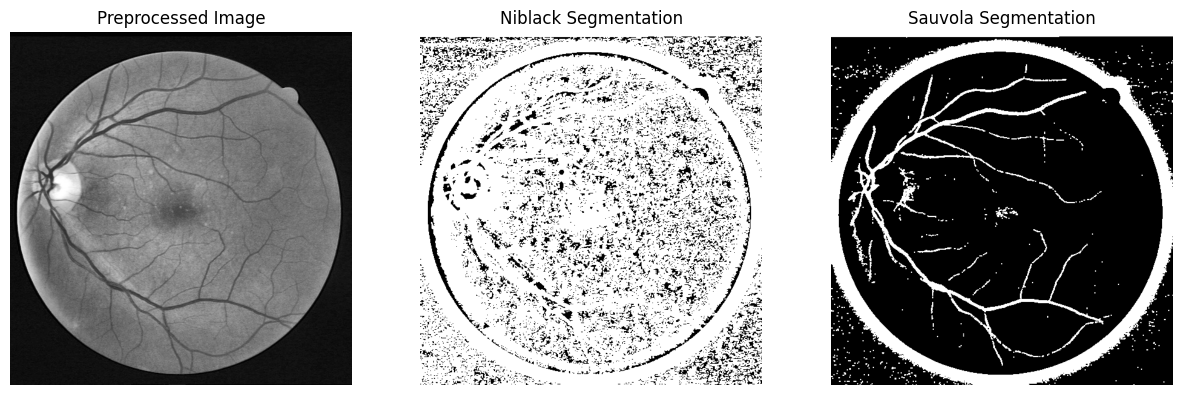

In [12]:


sample_index = 0

sample_img = enhance_green_channel(os.path.join(IMG_DIR, image_list[sample_index]))

niblack_output = apply_niblack(sample_img)
sauvola_output = apply_sauvola(sample_img)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(sample_img, cmap='gray')
plt.title("Preprocessed Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(niblack_output, cmap='gray')
plt.title("Niblack Segmentation")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(sauvola_output, cmap='gray')
plt.title("Sauvola Segmentation")
plt.axis("off")

plt.show()